# Environment Sanity Check

**Phase 2 — `StimulationEnv`**

Verifies four properties:
1. Transition probabilities sum to 1.0 for every (state, action) pair  
2. Observation probabilities sum to 1.0 for every (site, patient_state) pair in all settings  
3. A random policy over 1000 episodes produces a plausible state distribution  
4. Every episode terminates exactly at horizon `I`

In [1]:
import sys
sys.path.insert(0, '..')   # make src importable from notebooks/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.env.stimulation_env import (
    StimulationEnv,
    PATIENT_TRANSITION, OBS_PROBS,
    SITES, PATIENT_STATES, OBSERVATIONS,
    N_ACTIONS, N_PATIENT_STATES, N_OBS,
    VALID_SETTINGS,
)

PASS = '\u2705'  # green tick
FAIL = '\u274c'  # red cross

## 1. Patient state transition probabilities sum to 1.0

In [2]:
rows = []
all_ok = True
for (ps_idx, is_same), probs in PATIENT_TRANSITION.items():
    total = probs.sum()
    ok = abs(total - 1.0) < 1e-9
    all_ok = all_ok and ok
    rows.append({
        'patient_state': PATIENT_STATES[ps_idx],
        'is_same_site':  is_same,
        'p_baseline':    probs[0],
        'p_receptive':   probs[1],
        'p_non_receptive': probs[2],
        'sum':           round(total, 10),
        'ok':            PASS if ok else FAIL,
    })

df = pd.DataFrame(rows)
print(f'Overall: {PASS if all_ok else FAIL}\n')
df

Overall: ✅



,patient_state,is_same_site,p_baseline,p_receptive,p_non_receptive,sum,ok
0,baseline,False,0.6,0.3,0.1,1.0,✅
1,baseline,True,0.6,0.3,0.1,1.0,✅
2,receptive,True,0.2,0.3,0.5,1.0,✅
3,receptive,False,0.5,0.3,0.2,1.0,✅
4,non_receptive,True,0.1,0.1,0.8,1.0,✅
5,non_receptive,False,0.4,0.3,0.3,1.0,✅


## 2. Observation probabilities sum to 1.0 (all settings)

In [3]:
rows = []
all_ok = True
for setting in VALID_SETTINGS:
    for site_idx, site in enumerate(SITES):
        for ps_idx, ps in enumerate(PATIENT_STATES):
            probs = OBS_PROBS[setting][site_idx, ps_idx]
            total = probs.sum()
            ok = abs(total - 1.0) < 1e-9
            all_ok = all_ok and ok
            rows.append({
                'setting':       setting,
                'site':          site,
                'patient_state': ps,
                'p_favorable':   probs[0],
                'p_neutral':     probs[1],
                'p_unfavorable': probs[2],
                'sum':           round(total, 10),
                'ok':            PASS if ok else FAIL,
            })

df = pd.DataFrame(rows)
print(f'Overall: {PASS if all_ok else FAIL}\n')
df

Overall: ✅



,setting,site,patient_state,p_favorable,p_neutral,p_unfavorable,sum,ok
0,high,S1,baseline,0.70,0.20,0.10,1.0,✅
1,high,S1,receptive,0.85,0.10,0.05,1.0,✅
2,high,S1,non_receptive,0.30,0.40,0.30,1.0,✅
3,high,S2,baseline,0.50,0.30,0.20,1.0,✅
4,high,S2,receptive,0.65,0.25,0.10,1.0,✅
5,high,S2,non_receptive,0.20,0.40,0.40,1.0,✅
6,high,S3,baseline,0.30,0.40,0.30,1.0,✅
7,high,S3,receptive,0.45,0.35,0.20,1.0,✅
8,high,S3,non_receptive,0.15,0.35,0.50,1.0,✅
9,high,S4,baseline,0.45,0.35,0.20,1.0,✅


## 3. Random policy — state distribution over 1000 episodes

Expected: baseline dominates early steps; receptive/non-receptive build up as the agent repeatedly hits the same sites.

In [4]:
N_EPISODES = 1000
HORIZON    = 10
env = StimulationEnv(setting='high', horizon=HORIZON, c_switch=0.0, seed=0)
rng = np.random.default_rng(0)

site_counts = np.zeros(5)          # 0=Start .. 4=S4
ps_counts   = np.zeros(3)          # baseline / receptive / non_receptive
step_ps     = np.zeros((HORIZON, 3))   # patient-state distribution per timestep

for _ in range(N_EPISODES):
    state = env.reset()
    done  = False
    while not done:
        action = int(rng.integers(N_ACTIONS))
        next_state, _, done, _ = env.step(action)
        site_idx, ps_idx, t = next_state
        site_counts[site_idx] += 1
        ps_counts[ps_idx]     += 1
        if t < HORIZON:
            step_ps[t, ps_idx] += 1

# --- site visit fractions ---
site_labels = ['Start'] + SITES
site_fracs  = site_counts / site_counts.sum()
print('Site visit fractions (Start should be ~0 after t=0):')
for label, frac in zip(site_labels, site_fracs):
    print(f'  {label:5s}: {frac:.3f}')

# --- patient-state fractions ---
ps_fracs = ps_counts / ps_counts.sum()
print('\nPatient-state fractions:')
for label, frac in zip(PATIENT_STATES, ps_fracs):
    print(f'  {label:15s}: {frac:.3f}')

Site visit fractions (Start should be ~0 after t=0):
  Start: 0.000
  S1   : 0.253
  S2   : 0.244
  S3   : 0.250
  S4   : 0.253

Patient-state fractions:
  baseline       : 0.501
  receptive      : 0.295
  non_receptive  : 0.204


/var/folders/pm/h3h784_n66g_91_3hsdrrjcw0000gp/T/ipykernel_24924/879614933.py:2: RuntimeWarning: invalid value encountered in divide
  step_ps_norm = step_ps / step_ps.sum(axis=1, keepdims=True)


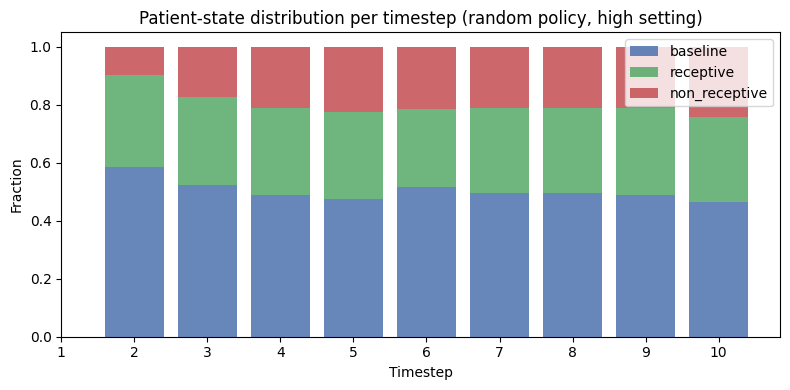

In [5]:
# Patient-state distribution across timesteps
step_ps_norm = step_ps / step_ps.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(8, 4))
bottom = np.zeros(HORIZON)
colors = ['#4C72B0', '#55A868', '#C44E52']
for i, (label, color) in enumerate(zip(PATIENT_STATES, colors)):
    ax.bar(range(1, HORIZON + 1), step_ps_norm[:, i], bottom=bottom,
           label=label, color=color, alpha=0.85)
    bottom += step_ps_norm[:, i]

ax.set_xlabel('Timestep')
ax.set_ylabel('Fraction')
ax.set_title('Patient-state distribution per timestep (random policy, high setting)')
ax.legend(loc='upper right')
ax.set_xticks(range(1, HORIZON + 1))
plt.tight_layout()
plt.savefig('../figures/sanity_patient_state_dist.png', dpi=150)
plt.show()

## 4. Episode terminates exactly at horizon `I`

In [6]:
all_ok = True
for horizon in [1, 5, 10]:
    env_h = StimulationEnv(horizon=horizon, seed=0)
    rng_h = np.random.default_rng(0)
    for ep in range(100):
        env_h.reset()
        done  = False
        steps = 0
        while not done:
            _, _, done, _ = env_h.step(int(rng_h.integers(N_ACTIONS)))
            steps += 1
        if steps != horizon:
            print(f'{FAIL} horizon={horizon} episode={ep}: lasted {steps} steps')
            all_ok = False
    if all_ok:
        print(f'{PASS} horizon={horizon:2d} — all 100 episodes lasted exactly {horizon} step(s)')

print(f'\nOverall: {PASS if all_ok else FAIL}')

✅ horizon= 1 — all 100 episodes lasted exactly 1 step(s)
✅ horizon= 5 — all 100 episodes lasted exactly 5 step(s)
✅ horizon=10 — all 100 episodes lasted exactly 10 step(s)

Overall: ✅


## 5. `decode_state` human-readable helper

In [7]:
examples = [(0,0,0), (1,0,1), (1,1,3), (4,2,10)]
for s in examples:
    print(f'{s}  ->  {StimulationEnv.decode_state(s)}')

(0, 0, 0)  ->  Start/baseline/t=0
(1, 0, 1)  ->  S1/baseline/t=1
(1, 1, 3)  ->  S1/receptive/t=3
(4, 2, 10)  ->  S4/non_receptive/t=10


## 6. `get_transition_probs` — probabilities sum to 1.0 for all (state, action)

In [8]:
env = StimulationEnv(setting='high', horizon=10)
states_to_check = [(0,0,0), (1,0,1), (1,1,2), (2,2,5), (4,2,9)]

all_ok = True
for state in states_to_check:
    for action in range(N_ACTIONS):
        outcomes = env.get_transition_probs(state, action)
        total    = sum(p for _, _, p in outcomes)
        ok       = abs(total - 1.0) < 1e-9
        all_ok   = all_ok and ok
        status   = PASS if ok else f'{FAIL} sum={total:.6f}'
        print(f'{StimulationEnv.decode_state(state):25s}  action=S{action+1}  {status}')

print(f'\nOverall: {PASS if all_ok else FAIL}')

Start/baseline/t=0         action=S1  ✅
Start/baseline/t=0         action=S2  ✅
Start/baseline/t=0         action=S3  ✅
Start/baseline/t=0         action=S4  ✅
S1/baseline/t=1            action=S1  ✅
S1/baseline/t=1            action=S2  ✅
S1/baseline/t=1            action=S3  ✅
S1/baseline/t=1            action=S4  ✅
S1/receptive/t=2           action=S1  ✅
S1/receptive/t=2           action=S2  ✅
S1/receptive/t=2           action=S3  ✅
S1/receptive/t=2           action=S4  ✅
S2/non_receptive/t=5       action=S1  ✅
S2/non_receptive/t=5       action=S2  ✅
S2/non_receptive/t=5       action=S3  ✅
S2/non_receptive/t=5       action=S4  ✅
S4/non_receptive/t=9       action=S1  ✅
S4/non_receptive/t=9       action=S2  ✅
S4/non_receptive/t=9       action=S3  ✅
S4/non_receptive/t=9       action=S4  ✅

Overall: ✅
